<div style="text-align: justify">

# **Credit Derivatives Modelling**

This notebook presents a complete pipeline in Python for a three-steps assignment on Credit Derivatives. In particular, the assignment can be divided in two distinct blocks: the first asks to compute discount factors starting from the Euribor swap curve and, with those and a given matrix of CDS spreads for six entities, to recover survival and default probabilities for each name; the second guides the student through the process of pricing a multiname credit derivative based on a basket of five entities, starting from a given time series of CDS spreads. Each step of the assignment is further presented below.
<br/><br/>

**1. Compute the zero coupon bond curve**\
Take the Euribor-swap curve in sheet ‘swap curve” in the file “market data2023.xlsx”. Calibrate the Nelson-Siegel-Svensson model to the rates in column B in order to interpolate the swap rates each years from 1 year to 30 years. Then apply bootsptrapping technique to compute the price of zero risk free coupon bonds. Be careful: the rates with maturity of less than 1 year are zero rates and we do not have to bootstrap them.

**2. Compute default probabilities**\
Take the CDS spreads quoted in bps as in the sheet “CDS spread” in the file “market data 2023.xlsx”. Compute the default & survival risk neutral probabilities boostrapping the CDS spread curve considering a time inhomogeneous Poisson process with piece constant intensity rate. In particular, consider the intensity rate to be constant between two consecutive quoted CDS spread.

**3. Pricing a Multiname Credit Derivative**\
Suppose our trading desk ask you to price a multiname credit derivative whose payoff is defined as follow: you receive 1 Euro at maturity if no name of the underlying pool defaults until maturity, zero otherwise. The maturity is 5 years and the pool of name is constituted by ENI, Unicredit, Volkswagen, Allianz, Iberdrola. The fair value FV of that derivative is defined by $$ FV = E^Q[D(0,5)\prod_{i=1}^{5}1_{\tau_{i}>5}] $$ Under the assumption of independence between interest rates and default times, we have $$ FV = P(0,5)E^Q[\prod_{i=1}^{5}1_{\tau_{i}>5}] $$ Compute the FV by Monte Carlo simulation using an intensity model with constant hazard rate for each name in the pool and the Gaussian copula (setP (0, 5) = 0.95). Follow the steps:
- fit the Gaussian copula the the time series of CDS spread in the file “CDS time series.xlsx”. For each name, transform the CDS spread into the 5-years default probability using for each time t in the time series the formula: $$ 1-e^{-5\times{CDS_{i}(t)}/(1-REC_{i})} $$ where i ∈ 1, . . . , 5 denotes a name in the pool. Set $REC_{i} = 0.4$ for each i (Remember: express the CDS spreads in bps).
- transform the time series of default probabilities obtained in the previous step into pseudo uniform number using the rank function (or the empirical CDF for example).
- fit the Gaussian copula to the time series of pseudo uniform number obtained in the previous step.
- using the correlation matrix C obtained in the previous fitting, sample multivariate normal random variable X with zero mean and correlation C. (hint: decompose the correlation matrix C with Cholesky)
- sample uniform random variable $U = \phi(X)$, where $\phi$ is the standard normal comulative function.
- simulate the default time of each name in the pool using the formula: $$ \{\tau_{i}>5\} = \{\int_{0}^{5}\lambda_{i}dt < -\ln(1 - U_{i})\} $$ For each name in the pool, compute $\lambda_{i}$ calibrating an intensity model with constant hazard rate to the last CDS spread in the time series (hint: use the credit triangle equality).

<br/><br/>
The two Excel files containing the data for the assignment, "market_data2023.xlsx" and "CDS_time_series.xlsx", are included in the subfolder "./data". Final outputs from each step and any relevant intermediate result will be saved in the subfolder "./outputs".

Due to the modularity of the assignment, each step will be handled in a separate paragraph; introducing each code implementation there is a brief summary of the main theoretical concepts required for the exercise.

The code relies on the main Python libraries (NumPy, Pandas, SciPy, Matplotlib) as well as a personal library containing the main functions specific for this assignment; the reason behind this modularity is the intent to create and maintain a collection of the main functions met across all projects to have an easy future access to them in case they might come of use again. To access this library, one can simply run the command "pip install git+https://www.github.com/rickyra01/myLib.git"; information on it can be found on the GitHub page of the repository.
</div>

### 1. The ZCB curve

#### 1.1 Introduction

<div style="text-align: justify">

#### The Zero Coupon Bond Curve

A **zero coupon bond** (ZCB) with maturity $T$ is a contract that pays 1 unit of currency at time $T$ with no intermediate cash flows. Its price at time 0, denoted $P(0, T)$, coincides with the **discount factor** $D(0, T)$: the present value of one unit of currency delivered at $T$. The term structure of these prices across maturities constitutes the ZCB curve, a fundamental object in fixed income and derivatives pricing.

In practice, ZCB prices are not directly observable for all maturities. The standard approach is to extract them from quoted market instruments — in this case, the **Euribor swap curve** — through two steps: curve fitting and bootstrapping.

**Nelson-Siegel-Svensson model.** The NSS model provides a parametric representation of the yield curve:

$$
r(t) = \beta_0 + \beta_1 \frac{1 - e^{-t/\tau_1}}{t/\tau_1} + \beta_2 \left(\frac{1 - e^{-t/\tau_1}}{t/\tau_1} - e^{-t/\tau_1}\right) + \beta_3 \left(\frac{1 - e^{-t/\tau_2}}{t/\tau_2} - e^{-t/\tau_2}\right)
$$

The six parameters $(\beta_0, \beta_1, \beta_2, \beta_3, \tau_1, \tau_2)$ control the level, slope, and two curvature components of the curve. The model is calibrated by minimising the distance between observed swap rates and model-implied rates. Once calibrated, it allows interpolation of the swap rate at any maturity — here, at each integer year from 1 to 30.

**Bootstrapping.** Given a set of swap rates, bootstrapping is a sequential procedure to strip discount factors maturity by maturity. A fixed-rate swap with rate $s_T$ and annual payments has zero net present value at inception, which gives the no-arbitrage condition:

$$
s_T \sum_{k=1}^{T} P(0, k) + P(0, T) = 1
$$

Rearranging, one can express $P(0, T)$ in terms of the already-computed $P(0, 1), \ldots, P(0, T-1)$, bootstrapping the curve forward one maturity at a time. For maturities below one year, where rates are quoted as zero rates rather than swap rates, discount factors are computed directly as $P(0, T) = 1 / (1 + r \cdot T)$.

</div>

#### 1.2 Implementation

In [15]:
import os
import numpy as np
import pandas as pd
from myLib import calibration_nss, display_nss, bootstrap_df

BASE_DIR = os.getcwd()
DATA_PATH = os.path.join(BASE_DIR, "data", "market_data2023.xlsx")
OUTPUT_DIR = os.path.join(BASE_DIR, "outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

data = pd.read_excel(DATA_PATH,
                    sheet_name= 'swap curve',
                    header = 2,
                    usecols= 'A:B',
                    nrows = 18)
data

,Maturity,Swap rates (in %)
0,0.083333,2.516
1,0.250000,2.647
2,0.500000,3.080
3,0.750000,3.140
4,1.000000,3.239
5,2.000000,2.833
6,3.000000,2.625
7,4.000000,2.463
8,5.000000,2.405
9,6.000000,2.355


Optimized parameters:
[ 0.01787358  0.01989704 -2.95870917  2.94675853  4.97089235  5.0275986 ]


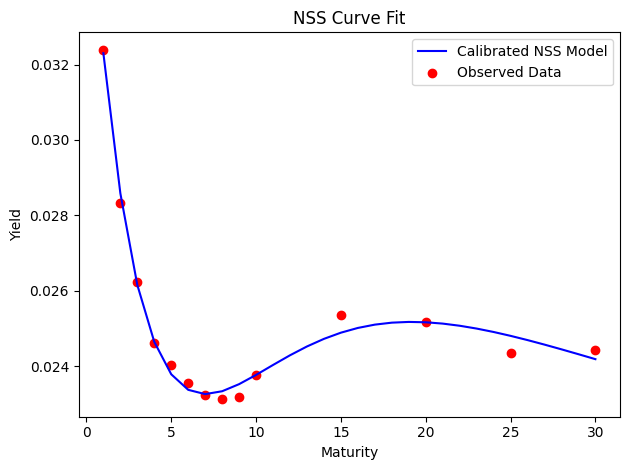

       Discount Factors
0.08           0.997799
0.25           0.992359
0.50           0.984543
0.75           0.976348
1.00           0.972206
2.00           0.945184
3.00           0.925627
4.00           0.907545
5.00           0.889603
6.00           0.871148
7.00           0.851953
8.00           0.832046
9.00           0.811595
10.00          0.790833
11.00          0.770005
12.00          0.749345
13.00          0.729051
14.00          0.709287
15.00          0.690177
16.00          0.671806
17.00          0.654230
18.00          0.637473
19.00          0.621541
20.00          0.606421
21.00          0.592084
22.00          0.578497
23.00          0.565618
24.00          0.553400
25.00          0.541797
26.00          0.530764
27.00          0.520253
28.00          0.510221
29.00          0.500627
30.00          0.491434


In [16]:
# NSS curve fit

nss_df = data[data["Maturity"] >= 1]
maturities = nss_df["Maturity"]
rates = nss_df["Swap rates (in %)"] / 100
t_grid = np.arange(1, maturities.iloc[-1] + 1)

nss_curve, optimized_params = calibration_nss(maturities, rates, output_maturities = t_grid)
print(f"Optimized parameters:\n{optimized_params}")
display_nss(nss_curve, maturities, rates)

optimized_params = pd.DataFrame(optimized_params, index=["beta0", "beta1", "beta2", "beta3", "tau1", "tau2"])
optimized_params.to_csv(os.path.join(OUTPUT_DIR, "nss_parameters.csv"), index=True)


# Getting Discount factors

rates = np.concatenate((data[data["Maturity"] < 1]["Swap rates (in %)"].to_numpy() / 100, nss_curve["NSS Predictions"]))
maturities = np.concatenate((data[data["Maturity"] < 1]["Maturity"].to_numpy(), nss_curve["Maturities"]), dtype=float)
bootstrap = bootstrap_df(rates, maturities)
dfs = pd.DataFrame({
    "Discount Factors": bootstrap
}, index = np.round(maturities, 2))
print(dfs)

dfs.to_csv(os.path.join(OUTPUT_DIR, "discount_factors.csv"), index=False)

### 2. Survival and default probabilities

#### 2.1 Introduction

<div style="text-align: justify">

#### Credit Risk and Default Probabilities

In credit risk modelling, the fundamental quantity of interest is the **default time** $\tau$ of an obligor — the (random) time at which it fails to meet its obligations. Under the risk-neutral measure $\mathbb{Q}$, the central objects derived from $\tau$ are:

- the **survival probability** $q(t) = \mathbb{Q}(\tau > t)$: the probability that the entity has not defaulted by time $t$;
- the **default probability** $F(t) = 1 - q(t) = \mathbb{Q}(\tau \leq t)$.

**Intensity models.** In the reduced-form (intensity) approach, the default time is modelled as the first jump of a **Poisson process** with intensity $\lambda(t)$, also called the **hazard rate**. Under the assumption of a time-inhomogeneous process with piecewise-constant intensity — constant between consecutive quoted maturities — the survival probability takes the form:

$$
q(t) = \exp\!\left(-\int_0^t \lambda(s)\, ds\right) = \exp\!\left(-\sum_{k} \lambda_k \,\Delta t_k\right)
$$

where the sum runs over the intervals $[t_{k-1}, t_k]$ contained in $[0, t]$.

**CDS spreads and calibration.** A **Credit Default Swap** (CDS) is a contract in which the protection buyer pays a periodic spread $s$ in exchange for a payment of $(1 - R)$ (the Loss Given Default, where $R$ is the recovery rate) upon default. At fair value, the present value of the **premium leg** equals that of the **protection leg**:

$$
s \sum_i D(0, t_i)\, q(t_i)\, \Delta t_i = (1-R) \sum_i D(0, t_i)\, [q(t_{i-1}) - q(t_i)]
$$

This no-arbitrage condition links the quoted CDS spread directly to the survival probabilities — and hence to the hazard rates. Bootstrapping the CDS spread curve, maturity by maturity, allows the recovery of a full piecewise-constant hazard rate curve consistent with market quotes.

</div>

#### 2.2 Implementation

In [17]:
import matplotlib.pyplot as plt
from myLib import calibrate_hazard_curve, survival_probs

data = pd.read_excel(DATA_PATH,
                    header = 1,
                    index_col= 0,
                    usecols= 'B:H',
                    nrows = 11)
data = data.sort_index()

RECOVERY_RATE = 0.4
LGD = 1 - RECOVERY_RATE

#recovering dfs corresponding to the maturities in the data
DFS_PATH = os.path.join(OUTPUT_DIR, "discount_factors.csv")
# dfs = pd.read_csv(DFS_PATH, index_col= 0) #Load discount factors generated by zcb_curve.py

maturities = data.index.to_numpy(dtype = float)
dfs = dfs.loc[maturities].to_dict()[dfs.columns[0]]

data.head()
print(dfs, maturities)

{0.5: 0.9845426799251747, 1.0: 0.972205784265463, 2.0: 0.9451840869592238, 3.0: 0.9256273070254984, 4.0: 0.9075446194418295, 5.0: 0.8896031000569751, 7.0: 0.851953066751646, 10.0: 0.7908325369407286, 20.0: 0.6064205886017194, 30.0: 0.4914335684064875} [ 0.5  1.   2.   3.   4.   5.   7.  10.  20.  30. ]


In [18]:
#hazard rates calibration for each firm
hazard_rates = {}
for firm in data.columns:
    spreads = data.loc[maturities, firm] / 10000

    hazard_rates[firm] = calibrate_hazard_curve(maturities, spreads, dfs)

hazard_rates_table = pd.DataFrame(hazard_rates, index=maturities)

print("\nHazard Rates DataFrame:")
print(hazard_rates_table)


Hazard Rates DataFrame:
      Banco Santander       Eni     Ziggo  Lufthansa   Renault   Allianz
0.5          0.004018  0.003259  0.015533   0.015440  0.012156  0.002472
1.0          0.006079  0.005696  0.029134   0.024443  0.015491  0.004239
2.0          0.008596  0.008785  0.047288   0.026496  0.036541  0.005826
3.0          0.012140  0.013054  0.078058   0.033214  0.058707  0.008281
4.0          0.015929  0.017801  0.106201   0.053708  0.076882  0.010516
5.0          0.019739  0.022284  0.133568   0.067442  0.096463  0.012860
7.0          0.019853  0.027406  0.128969   0.060271  0.099660  0.014327
10.0         0.020622  0.030225  0.116162   0.057290  0.072911  0.016185
20.0         0.019381  0.027732  0.087837   0.049097  0.060315  0.015406
30.0         0.022915  0.034432  0.086562   0.053895  0.061546  0.019092


In [19]:
#survival and default probabilities calculation for each firm

survival_probabilities = {}
default_probabilities = {}
for firm in hazard_rates_table.columns:
    lambdas = hazard_rates_table[firm].to_numpy()
    times = hazard_rates_table.index.to_numpy()

    q = survival_probs(lambdas, times)

    survival_probabilities[firm] = q
    default_probabilities[firm] = 1 - np.array(q)

survival_probabilities_table = pd.DataFrame(survival_probabilities, index=maturities)
default_probabilities_table = pd.DataFrame(default_probabilities, index=maturities)

print("\nSurvival Probabilities DataFrame:")
print(survival_probabilities_table)

print("\nDefault Probabilities DataFrame:")
print(default_probabilities_table)


Survival Probabilities DataFrame:
      Banco Santander       Eni     Ziggo  Lufthansa   Renault   Allianz
0.5          0.997993  0.998372  0.992264   0.992310  0.993940  0.998765
1.0          0.994965  0.995533  0.977914   0.980256  0.986272  0.996650
2.0          0.986448  0.986825  0.932747   0.954624  0.950883  0.990861
3.0          0.974545  0.974027  0.862708   0.923438  0.896667  0.982689
4.0          0.959145  0.956842  0.775785   0.875150  0.830313  0.972409
5.0          0.940398  0.935755  0.678787   0.818074  0.753960  0.959984
7.0          0.903790  0.885845  0.524460   0.725174  0.617710  0.932868
10.0         0.849570  0.809055  0.370140   0.610662  0.496352  0.888653
20.0         0.699892  0.613113  0.153779   0.373746  0.271547  0.761770
30.0         0.556558  0.434515  0.064709   0.218028  0.146742  0.629371

Default Probabilities DataFrame:
      Banco Santander       Eni     Ziggo  Lufthansa   Renault   Allianz
0.5          0.002007  0.001628  0.007736   0.007690  0

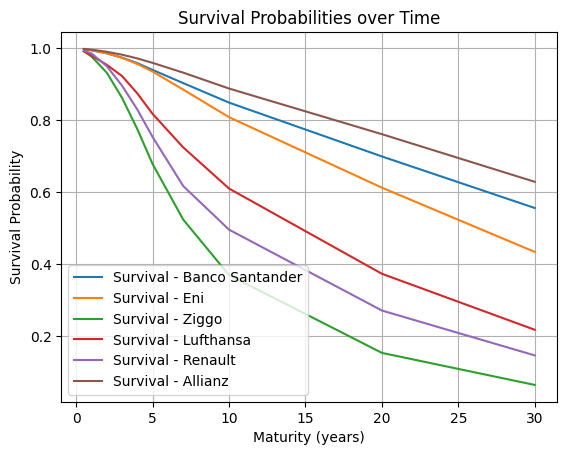

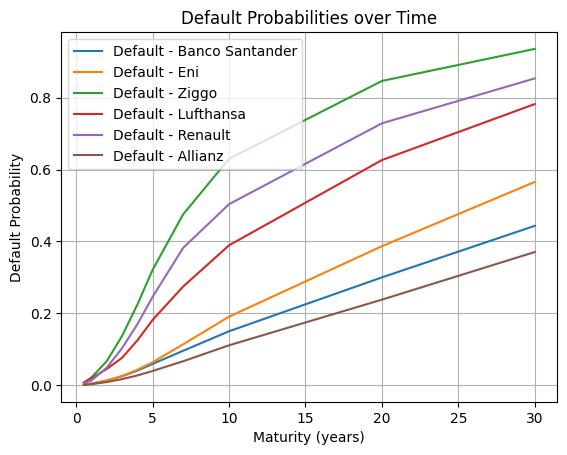

In [20]:
# Plotting survival and default probabilities for each firm

fig, ax = plt.subplots()
for firm in survival_probabilities_table.columns:
    ax.plot(maturities,
            survival_probabilities_table[firm],
            label=f'Survival - {firm}')
ax.set_xlabel('Maturity (years)')
ax.set_ylabel('Survival Probability')
ax.set_title('Survival Probabilities over Time')
ax.legend()
ax.grid()
plt.savefig(os.path.join(OUTPUT_DIR, "survival_probabilities_plot.png"))

fig, ax = plt.subplots()
for firm in default_probabilities_table.columns:
    ax.plot(maturities,
            default_probabilities_table[firm],
            label=f'Default - {firm}') 
ax.set_xlabel('Maturity (years)')
ax.set_ylabel('Default Probability')
ax.set_title('Default Probabilities over Time')
ax.legend()
ax.grid()
plt.savefig(os.path.join(OUTPUT_DIR, "default_probabilities_plot.png"))

plt.show()

In [21]:
# Output save 

hazard_rates_table.to_csv(os.path.join(OUTPUT_DIR, "hazard_rates.csv"))
survival_probabilities_table.to_csv(os.path.join(OUTPUT_DIR, "survival_probabilities.csv"))
default_probabilities_table.to_csv(os.path.join(OUTPUT_DIR, "default_probabilities.csv"))

### 3. Price of a multiname credit derivative

#### 3.1 Introduction

<div style="text-align: justify">

#### Multiname Credit Derivatives and the Gaussian Copula

A **multiname credit derivative** is a contract whose payoff depends on the joint default behaviour of a basket of obligors. Pricing such instruments requires modelling not only the marginal default probabilities of each name, but also their **dependence structure** — i.e., the likelihood that multiple names default together.

**The fair value.** The contract considered here pays €1 at maturity $T = 5$ if all names in the basket survive, and zero otherwise. Its fair value under the risk-neutral measure is:

$$
FV = \mathbb{E}^{\mathbb{Q}}\!\left[D(0,5)\prod_{i=1}^{5}\mathbf{1}_{\{\tau_i > 5\}}\right]
$$

Under the assumption of independence between interest rates and default times, the discount factor can be separated from the survival indicator:

$$
FV = P(0,5)\cdot\mathbb{E}^{\mathbb{Q}}\!\left[\prod_{i=1}^{5}\mathbf{1}_{\{\tau_i > 5\}}\right]
$$

The expectation is then estimated by **Monte Carlo simulation**.

**The Gaussian copula.** A copula is a multivariate distribution that couples marginal distributions while capturing their dependence. The **Gaussian copula** assumes that the dependence between default times is fully described by a correlation matrix $C$, through the following construction:

1. Sample a multivariate normal vector $X \sim \mathcal{N}(0, C)$, obtained via Cholesky decomposition $C = LL^\top$ applied to independent standard normals: $X = LZ$, $Z \sim \mathcal{N}(0, I)$.
2. Map to uniform marginals: $U_i = \Phi(X_i)$, where $\Phi$ is the standard normal CDF. By construction, each $U_i \sim \mathcal{U}(0,1)$ with the dependence structure encoded by $C$.
3. Map to default times using the inverse of the marginal survival function. Under a constant hazard rate $\lambda_i$ (calibrated via the **credit triangle** $\lambda_i \approx s_i / (1-R)$), the default time satisfies:

$$
\{\tau_i > 5\} = \left\{\lambda_i \cdot 5 < -\ln(1 - U_i)\right\}
$$

The correlation matrix $C$ is estimated empirically from a time series of CDS spreads, converted to pseudo-uniform observations via their empirical CDF (rank transform), and then back to the Gaussian scale via $\Phi^{-1}$.

</div>

#### 3.2 Implementation

In [22]:
from scipy.stats import norm

DATA_PATH = os.path.join(BASE_DIR, "data", "CDS_time_series.xlsx")

os.makedirs(OUTPUT_DIR, exist_ok=True)

cds_spread_ts = pd.read_excel(DATA_PATH,
                    header = 2,
                    index_col= 0,
                    usecols= 'A:F')

RECOVERY_RATE = 0.4 #constant recovery rate through companies and time
LGD = 1 - RECOVERY_RATE
P05 = 0.95
N_NAMES = len(cds_spread_ts.columns)


# Step 1
default_prob_ts = {}
for name in cds_spread_ts.columns:
    hazard_rates_ts = cds_spread_ts[name] / (1 - RECOVERY_RATE) / 10000
    default_prob_ts[name] = 1 - np.exp(-5 * hazard_rates_ts)

default_prob_ts = pd.DataFrame(default_prob_ts, index=cds_spread_ts.index)


# Step 2
uniform_ts = default_prob_ts.rank(method='average') / (len(default_prob_ts) + 1)


# Step 3
EPS = 1e-6
uniform_ts = uniform_ts.clip(EPS, 1 - EPS)
gaussian_ts = uniform_ts.apply(norm.ppf) # ~ N(0,1)
corr_matrix = gaussian_ts.corr()
print(f'Correlation Matrix:\n{corr_matrix}')
corr_matrix.to_csv(os.path.join(OUTPUT_DIR, "correlation_matrix.csv"))


# Step 4
C = corr_matrix.values # correlation matrix
try:
    l = np.linalg.cholesky(C) # c = l @ l.T
except np.linalg.LinAlgError:
    raise RuntimeError("Correlation matrix not positive definite")

N_SIM = 100_000
z = np.random.randn(N_NAMES, N_SIM) # ~ N(0, I)
x = l @ z # ~ N(0, c)


# Step 5
u = norm.cdf(x) # ~ U(0,1)


# Step 6
last_cds = cds_spread_ts.iloc[-1] /10000
lambdas = last_cds / LGD

tau = np.zeros_like(u)
for i, name in enumerate(lambdas.index):
    tau[i, :] = -np.log(1 - u[i, :]) / lambdas[name]

payoff = (tau.min(axis=0) > 5).astype(float) # payoff for each simulation
fv = P05 * payoff.mean() # fair value of the CDS
print(f'FV = {fv}')

Correlation Matrix:
                 ENI  Unicredit  Volkswagen   Allianz  Iberdrola
ENI         1.000000   0.741847    0.848969  0.619041   0.044738
Unicredit   0.741847   1.000000    0.843874  0.723123   0.469740
Volkswagen  0.848969   0.843874    1.000000  0.714370   0.231997
Allianz     0.619041   0.723123    0.714370  1.000000   0.527168
Iberdrola   0.044738   0.469740    0.231997  0.527168   1.000000
FV = 0.7557725
